In [ ]:
#write your code here

import pandas as pd
data = pd.read_excel("https://confrecordings.ams3.digitaloceanspaces.com/countries.xlsx")
print(data.head)
print(data.shape)
print(data.isnull().sum())
data.dropna(inplace = True)
print(data.isnull().sum())

<bound method NDFrame.head of     country   latitude  longitude                  name
0        AD  42.546245   1.601554               Andorra
1        AE  23.424076  53.847818  United Arab Emirates
2        AF  33.939110  67.709953           Afghanistan
3        AG  17.060816 -61.796428   Antigua and Barbuda
4        AI  18.220554 -63.068615              Anguilla
..      ...        ...        ...                   ...
240      YE  15.552727  48.516388                 Yemen
241      YT -12.827500  45.166244               Mayotte
242      ZA -30.559482  22.937506          South Africa
243      ZM -13.133897  27.849332                Zambia
244      ZW -19.015438  29.154857              Zimbabwe

[245 rows x 4 columns]>
(245, 4)
country      1
latitude     1
longitude    1
name         0
dtype: int64
country      0
latitude     0
longitude    0
name         0
dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

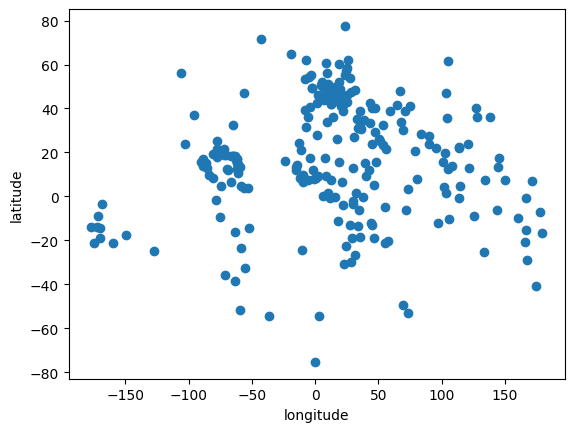

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(data['longitude'],data['latitude'])
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.show

In [ ]:
from sklearn.cluster import KMeans
xfeatures = data[['longitude','latitude']]
km = KMeans(n_clusters = 7, random_state=42)
clusters = km.fit_predict(xfeatures)
print(km.labels_)
print(km.cluster_centers_)
data['cluster_continents'] = clusters
print(data.head())



[6 0 0 4 4 6 0 4 3 3 4 1 6 2 4 0 6 4 5 6 3 6 0 3 3 4 5 4 4 4 5 3 3 6 4 4 5
 3 3 3 6 3 1 4 3 5 4 4 4 6 5 0 6 6 0 6 4 4 6 4 6 0 6 0 6 0 6 2 4 2 6 6 3 6
 4 0 4 6 3 6 6 6 3 4 3 6 4 4 2 6 4 0 5 3 4 6 4 6 5 6 0 6 5 5 0 0 6 6 6 4 0
 5 3 0 5 1 3 4 5 5 0 4 0 5 0 4 6 5 3 3 6 6 6 6 6 6 6 6 3 2 6 6 5 5 5 2 4 6
 4 6 3 5 3 4 5 3 2 6 2 3 4 6 6 5 2 1 2 0 4 4 1 2 5 0 6 4 1 4 0 6 2 4 0 3 6
 6 5 3 0 2 3 3 6 5 3 6 6 6 3 6 6 0 4 3 4 0 3 4 3 3 3 5 0 1 2 0 6 1 0 4 2 5
 3 6 3 4 4 0 6 4 4 4 4 5 2 1 1 6 0 3 3 3 3]
[[  48.25626737   30.05327491]
 [-164.167216    -15.7990057 ]
 [ 156.84523619   -7.98094281]
 [  22.75952849   -9.80893609]
 [ -69.68218541    8.58624816]
 [ 103.45510325   18.34838525]
 [   7.80604397   44.17186475]]
  country   latitude  longitude                  name  cluster_continents
0      AD  42.546245   1.601554               Andorra                   6
1      AE  23.424076  53.847818  United Arab Emirates                   0
2      AF  33.939110  67.709953           Afghanistan             

In [ ]:
#write your code here
print(data[data['cluster_continents']==0])
print(data[data['cluster_continents']==1])
print(data[data['cluster_continents']==2])
print(data[data['cluster_continents']==3])
print(data[data['cluster_continents']==4])
print(data[data['cluster_continents']==5])
print(data[data['cluster_continents']==6])
print(data.groupby('cluster_continents')['name'].count())



    country   latitude  longitude                     name  cluster_continents
1        AE  23.424076  53.847818     United Arab Emirates                   0
2        AF  33.939110  67.709953              Afghanistan                   0
6        AM  40.069099  45.038189                  Armenia                   0
15       AZ  40.143105  47.576927               Azerbaijan                   0
22       BH  25.930414  50.637772                  Bahrain                   0
51       CY  35.126413  33.429859                   Cyprus                   0
54       DJ  11.825138  42.590275                 Djibouti                   0
61       EG  26.820553  30.802498                    Egypt                   0
63       ER  15.179384  39.782334                  Eritrea                   0
65       ET   9.145000  40.489673                 Ethiopia                   0
75       GE  42.315407  43.356892                  Georgia                   0
91       GZ  31.354676  34.308825               Gaza

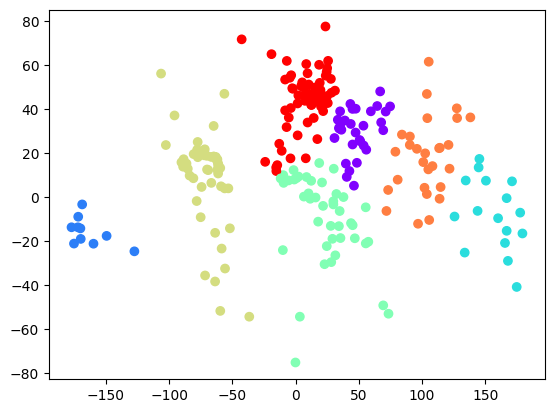

In [ ]:
plt.scatter(data['longitude'],data['latitude'],c=data['cluster_continents'],cmap='rainbow')
plt.show()

  country   latitude  longitude                  name  cluster_continents
0      AD  42.546245   1.601554               Andorra                   6
1      AE  23.424076  53.847818  United Arab Emirates                   0
2      AF  33.939110  67.709953           Afghanistan                   0
3      AG  17.060816 -61.796428   Antigua and Barbuda                   4
4      AI  18.220554 -63.068615              Anguilla                   4


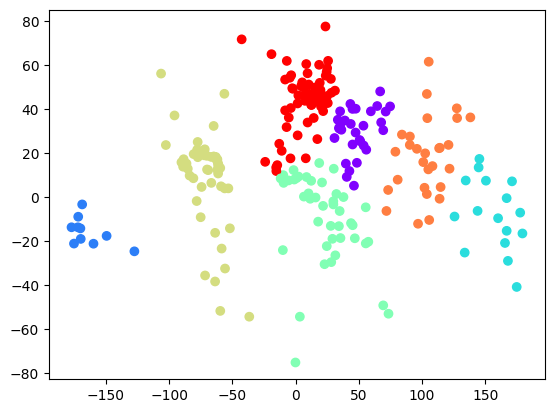

In [ ]:
from sklearn.cluster import DBSCAN
xfeatures = data[['longitude','latitude']]

data['cluster_continents'] = clusters

print(data.head())

plt.scatter(data['longitude'],data['latitude'],c=data['cluster_continents'],cmap='rainbow')

In [ ]:
pip install geopandas<1.0

/bin/bash: line 1: 1.0: No such file or directory


In [ ]:
import geopandas as gpd

g01 = gpd.GeoDataFrame(data,geometry=gpd.points_from_xy(data['longitude'],data['latitude']))
print(g01)

    country   latitude  longitude                  name  cluster_continents  \
0        AD  42.546245   1.601554               Andorra                   6   
1        AE  23.424076  53.847818  United Arab Emirates                   0   
2        AF  33.939110  67.709953           Afghanistan                   0   
3        AG  17.060816 -61.796428   Antigua and Barbuda                   4   
4        AI  18.220554 -63.068615              Anguilla                   4   
..      ...        ...        ...                   ...                 ...   
240      YE  15.552727  48.516388                 Yemen                   0   
241      YT -12.827500  45.166244               Mayotte                   3   
242      ZA -30.559482  22.937506          South Africa                   3   
243      ZM -13.133897  27.849332                Zambia                   3   
244      ZW -19.015438  29.154857              Zimbabwe                   3   

                       geometry  
0      POINT (1.6

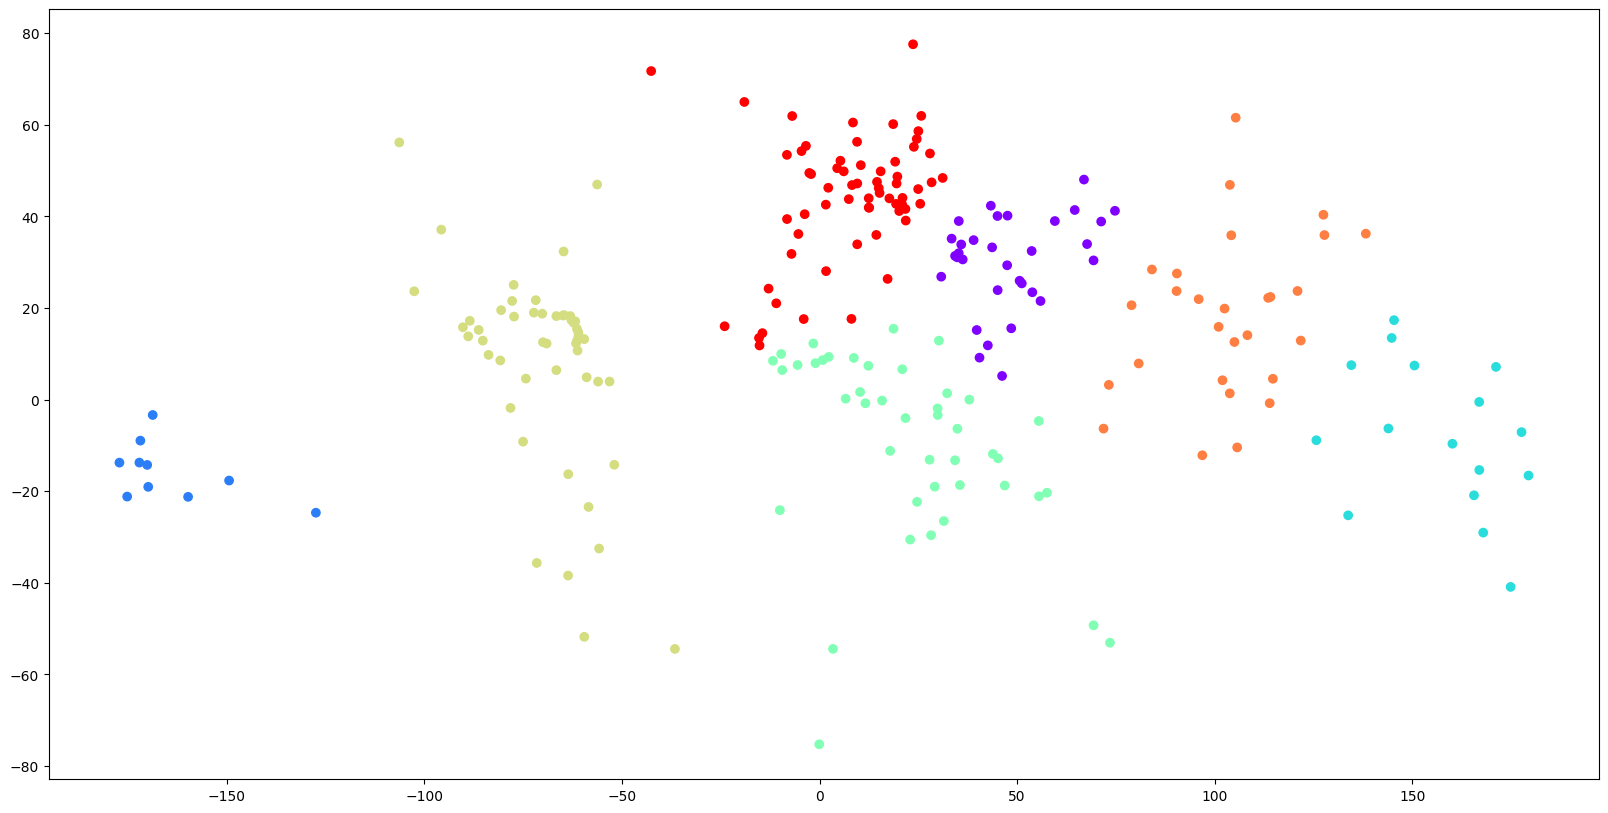

In [ ]:
plt.figure(figsize=(20,10))

plt.scatter(data['longitude'],data['latitude'],c=data['cluster_continents'],cmap='rainbow')

plt.show()

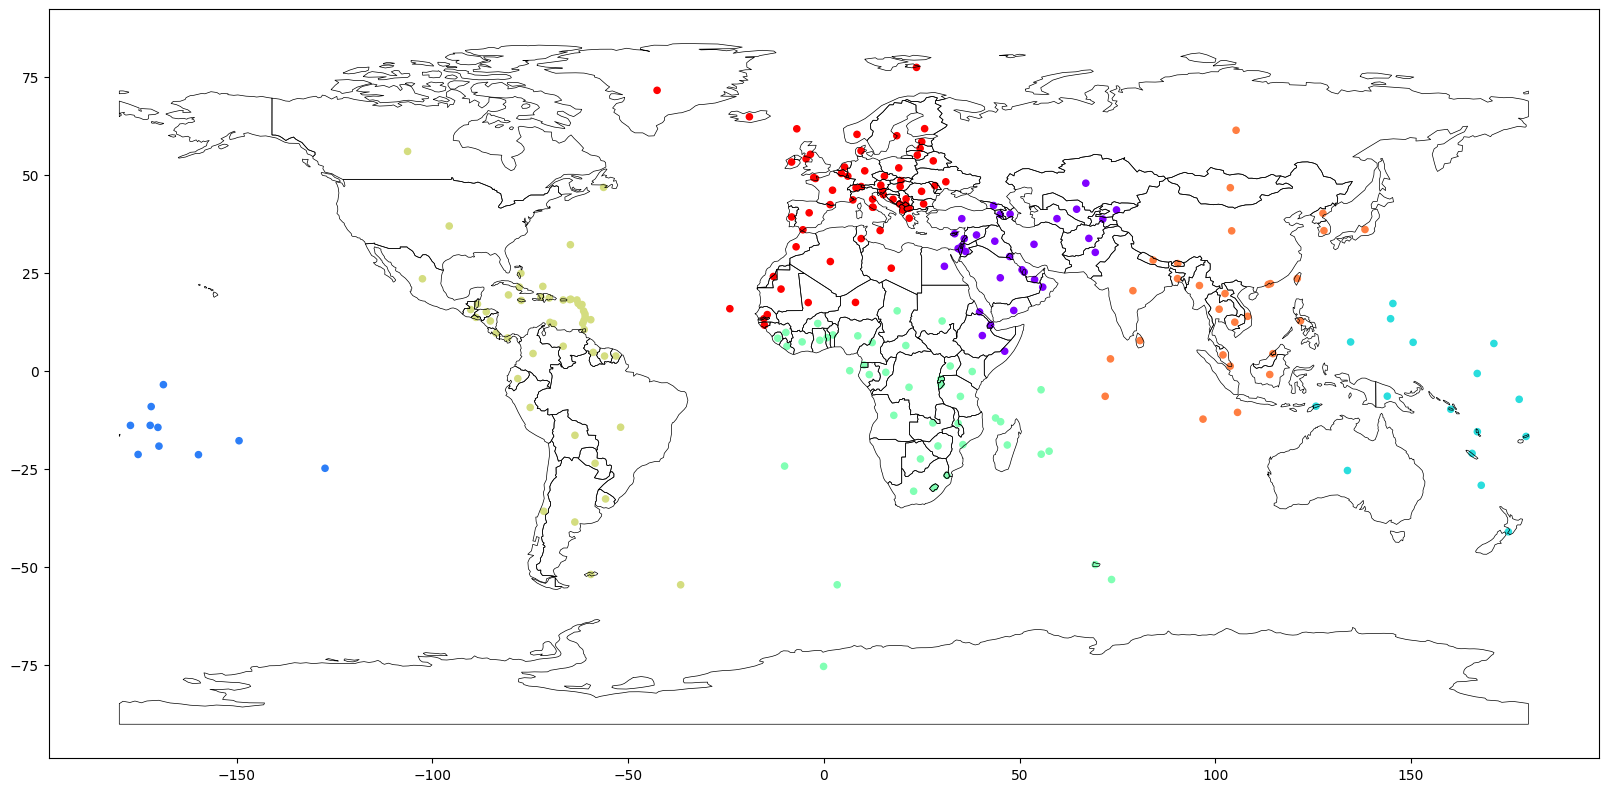

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)

fig, ax = plt.subplots(figsize=(20, 10))

world.boundary.plot(ax=ax, color="black", linewidth=0.5)

ax.scatter(
    data["longitude"],
    data["latitude"],
    c=data["cluster_continents"],
    cmap="rainbow",
    s=20
)

plt.show()



